In [82]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la
from scipy.integrate import solve_ivp
from numba import jit

In [83]:
#PDE functions
# Combine initial conditions into a single vector
def flatten_state(N, R):
    return np.concatenate([N.flatten(), R.flatten()])


def unflatten_state(y):
    N = y[:(S * nx)].reshape(S, nx)
    R = y[(S * nx):].reshape(M, nx)
    return N, R


def unflatten_state_end(y, S, M, nx):
    """
    Unflatten the state vector into two separate lists N and R.

    Parameters:
    y (list): Flattened state vector.
    S (int): Number of rows for N.
    M (int): Number of rows for R.
    nx (int): Number of columns for both N and R.

    Returns:
    tuple: Two lists N and R.
    """
    N = []
    R = []
    
    for i in range(S):
        N.append(y[i * nx:(i + 1) * nx])
    
    for i in range(M):
        R.append(y[(S * nx) + i * nx:(S * nx) + (i + 1) * nx])
    
    return N, R

def unflatten_ode_state(y):
    N = y[:S]
    R = y[S:]
    return N, R

# Define the PDE system as a set of ODEs using finite differences for spatial derivatives
def pde_system(y, t):
    N, R = unflatten_state(y)
    
    # Initialize derivatives
    dNdt = np.zeros((S, nx))
    dRdt = np.zeros((M, nx))
    
    # Calculate spatial derivatives using finite differences with periodic boundary
    def laplacian(u):
        u_left = np.roll(u, 1)
        u_right = np.roll(u, -1)
        return (u_left - 2*u + u_right) / (dx**2)
    
    # Calculate diffusion terms
    for i in range(S):
        #print(np.shape(N[i, :]))
        dNdt[i] += D_N[i] * laplacian(N[i, :])
    
    for alpha in range(M):
        dRdt[alpha] += D_R[alpha] * laplacian(R[alpha, :])
    
    # Calculate reaction terms for species
    for i in range(S):
        growth_term = 0
        for alpha in range(M):
            growth_term += (1 - l[i, alpha]) * w[alpha] * c_i_alpha[i, alpha] * R[alpha]
        dNdt[i] += N[i] * (growth_term - m[i])
    
    # Calculate reaction terms for resources
    for alpha in range(M):
        # Resource production and decay
        dRdt[alpha] += kappa[alpha] - rho[alpha] * R[alpha]
        
        # Consumption by species
        for i in range(S):
            dRdt[alpha] -= N[i] * c_i_alpha[i, alpha] * R[alpha]
        
        # Conversion from other resources
        for i in range(S):
            for beta in range(M):
                if beta != alpha:
                    dRdt[alpha] += N[i] * D_i_alpha_beta[i, alpha, beta] * l[i, beta] * (w[beta] / w[alpha]) * c_i_alpha[i, beta] * R[beta]

    return flatten_state(dNdt, dRdt)

def ode_system(y, t):
    N, R = unflatten_ode_state(y)
    
    # Initialize derivatives
    dNdt = np.zeros((S))
    dRdt = np.zeros((M))

    # Calculate reaction terms for species
    for i in range(S):
        growth_term = 0
        for alpha in range(M):
            growth_term += (1 - l[i, alpha]) * w[alpha] * c_i_alpha[i, alpha] * R[alpha]
        dNdt[i] += N[i] * (growth_term - m[i])
    
    # Calculate reaction terms for resources
    for alpha in range(M):
        # Resource production and decay
        dRdt[alpha] += kappa[alpha] - rho[alpha] * R[alpha]
        
        # Consumption by species
        for i in range(S):
            dRdt[alpha] -= N[i] * c_i_alpha[i, alpha] * R[alpha]
        
        # Conversion from other resources
        for i in range(S):
            for beta in range(M):
                if beta != alpha:
                    dRdt[alpha] += N[i] * D_i_alpha_beta[i, alpha, beta] * l[i, beta] * (w[beta] / w[alpha]) * c_i_alpha[i, beta] * R[beta]

    return flatten_state(dNdt, dRdt)


In [84]:
#unpack ODE solutions
def unpack_ode_solution(solution, t, S, M,stride):
    N = []
    R = []
    time = []


    for i in range(int(len(t)/stride)):

        tm = t[i*stride]
        time.append(tm)

        Ns, Rs = unflatten_ode_state(solution[i*stride])
        N.append(Ns.copy())
        R.append(Rs.copy())

    # Convert to numpy arrays for easier indexing
    N = np.array(N)
    R = np.array(R)

    time = np.array(time)

    # Check for steady state
    diff = np.abs(np.sum(N[-1]) - np.sum(N[-2]))
    if diff < 0.001:
        N_ss = N[-1]
        R_ss = R[-1]
    else:
        N_ss = None
        R_ss = None
        print("No steady state found")

    return N, R, time, N_ss, R_ss

In [85]:
def generate_initial_condition(S,M):

    """
    Generate a random initial condition for the MiCRM
    """
    
    #easy stuff first
    c = np.random.rand(S,M) #start with uniform random values
    w = np.random.rand(M) #resource quality
    l = np.random.rand(S,M) #resource leakiness
    m = np.abs(np.random.normal(loc=0.3, scale=0.1,size=(S))) #death rate, abs to prevent negative values
    
    #timescale blah blah
    tau = 1 #these are always fixed , but included for completeness
    B = 1/tau*m 
    
    #the diffusion constants
    D = np.random.rand(S)*1e-3 #diffusion constant for cells
    H = np.random.rand(M)*10 #diffusion constants for resources


    #040425 to start spatial vs well mixed we are going to assume batch culture
    k = np.zeros(M)
    r = np.zeros(M)


    #now the more complicated stuff
    CF_array = np.zeros((S,M,M)) # the MiCRM crossfeeding array (D_ab in their parlance)
    done = False
    for ii in range(S):
       for jj in range(M):
            
            while not done:
                matrix = np.random.rand(M)/M #crossfeeding array
                if np.sum(matrix) <= 1: #constrained such that the total resource leaked cannot be grater than the total resource earmarked for leakage
                    done = True
                else:
                    done = False
            done = False
            CF_array[ii,:,jj] = matrix
    
    N_ratios = np.random.rand(S) #initial ratios
    N_ratios = N_ratios/np.sum(N_ratios) #normalize ratios

    R_ratios = np.random.rand(M) #initial ratios
    R_ratios = R_ratios/np.sum(R_ratios) #normalize ratios

    return c,l,w,k,r,m,tau,CF_array,B,D,H,N_ratios,R_ratios

In [86]:
#generate initial condition
S = 3
M = 3

c_i_alpha,l,w,kappa,rho,m,tau,D_i_alpha_beta,B,D_N,D_R,N_ratios,R_ratios = generate_initial_condition(S,M)

In [87]:


#new steady state solver
N_0 = 1
R_0 = 100
t_final = 10
t_span = [0,t_final]
dt = 0.001
nt = int(t_final/dt)
t = np.linspace(0, t_final, nt)

N_init = np.zeros(S)
N_init[:] = N_0*N_ratios

R_init = np.zeros(M) + R_0*R_ratios

initial_state = flatten_state(N_init, R_init)

In [88]:
#solution = solve_ivp(ode_system, t_span, initial_state)
ode_solution = odeint(ode_system, initial_state, t)

N, R, time, Nss, Rss = unpack_ode_solution(ode_solution, t, S, M, 1)

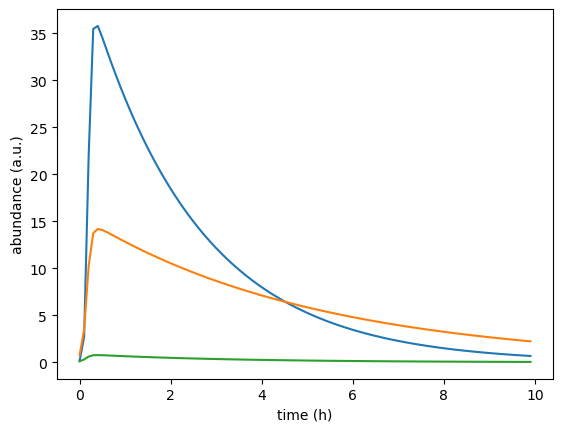

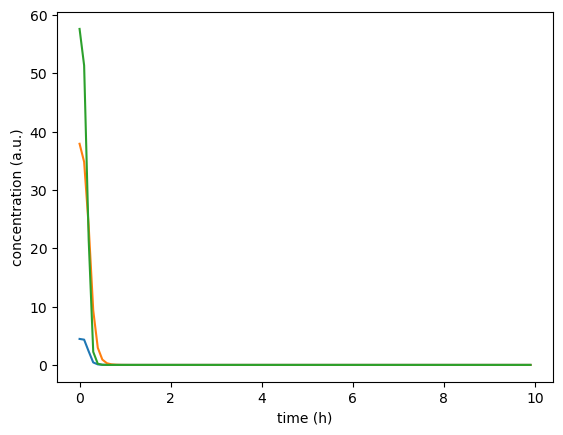

In [89]:
stride = 100
for nn in range(S):
    plt.plot(time[::stride],N.transpose()[nn,::stride],label='strain %s'%int(nn+1))
    #plt.axhline(y=Nss[nn])
#plt.legend()
#plt.axvline(x=Tss)
plt.xlabel('time (h)')
plt.ylabel('abundance (a.u.)')
plt.show()

for rr in range(M):
    plt.plot(time[::stride],R.transpose()[rr,::stride],label='resource %s'%int(rr+1))
#plt.legend()
plt.xlabel('time (h)')
plt.ylabel('concentration (a.u.)')
plt.show()

ODE_final = N.transpose()[:,-1]

In [90]:
#PDE properties
L = 10  # Spatial domain length
dx = 0.1
nx = int(L/dx)  # Number of spatial points
x = np.linspace(0, L, nx)  # Spatial grid

#initial conditions
mag = 0.01

N_init = np.zeros((S, nx))  # Both species at uniform density Nss
R_init = np.zeros((M, nx))

for xx in range(nx):
    for ss in range(S):
        N_init[ss,xx] = N_0*N_ratios[ss] + mag*np.random.normal()

    for rr in range(M):
        R_init[rr,xx] = R_0*R_ratios[rr] + mag*np.random.normal()

initial_state = flatten_state(N_init, R_init)

In [91]:
pde_solution = odeint(pde_system, initial_state, t)

In [92]:
# Extract solutions at different time points
N_solutions = []
R_solutions = []
tm = []

stride = 1

for i in range(int(len(t)/stride)):

    time = t[i*stride]
    tm.append(time)

    N, R = unflatten_state_end(pde_solution[i*stride],S,M,nx)
    N_solutions.append(N.copy())
    R_solutions.append(R.copy())


# Convert to numpy arrays for easier indexing
N_solutions = np.array(N_solutions,dtype="object")
R_solutions = np.array(R_solutions)

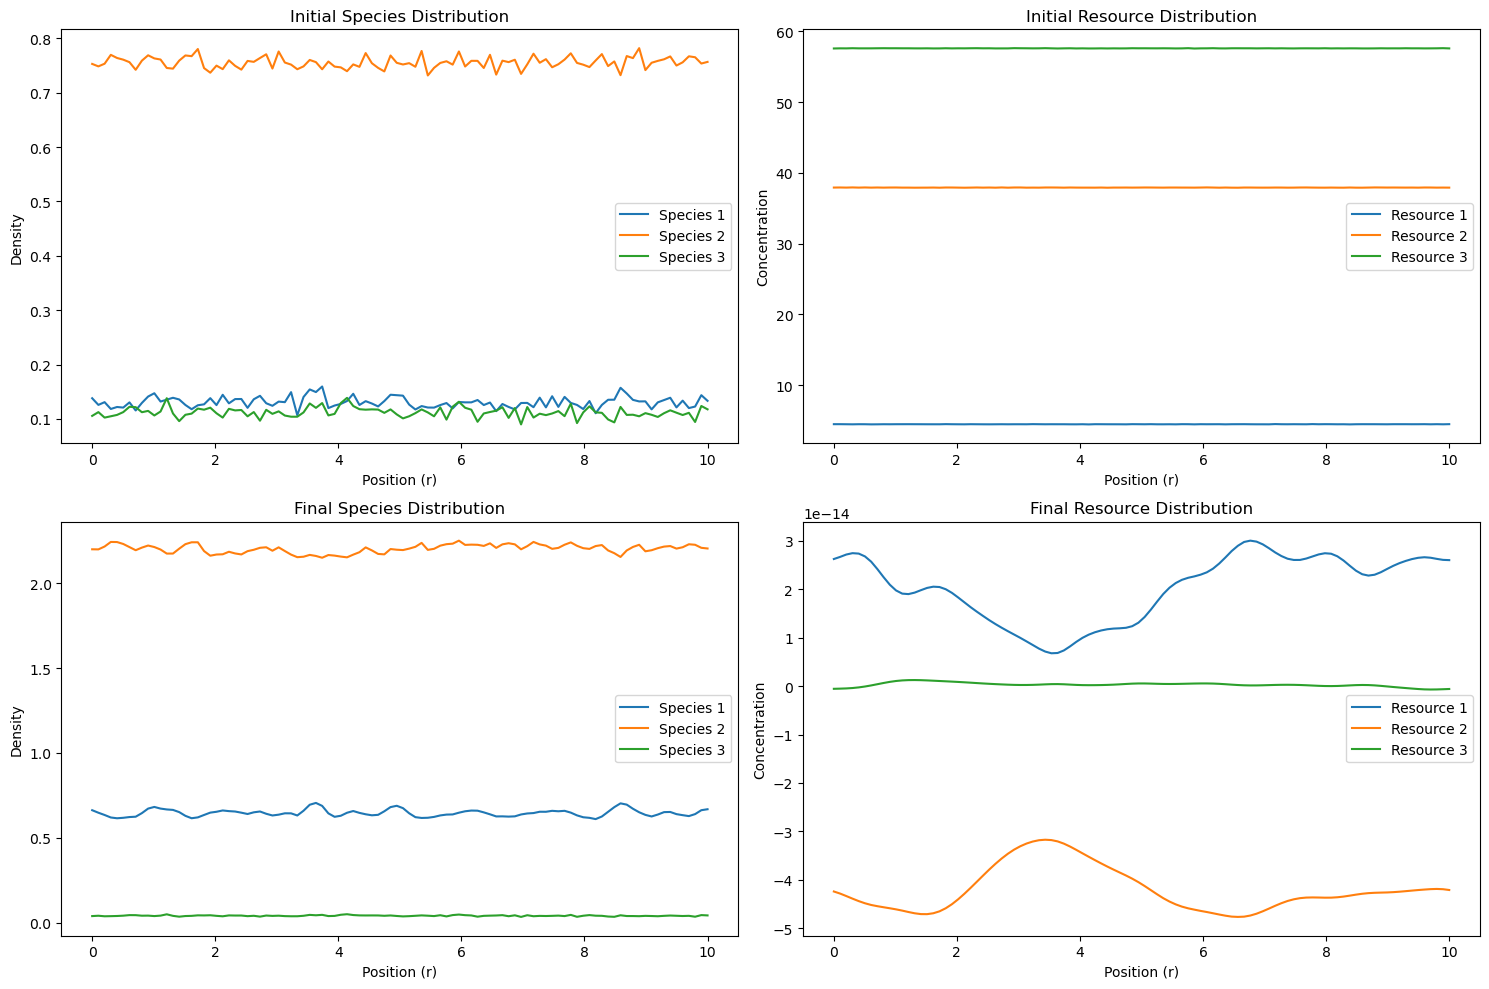

In [93]:
# Plot initial and final states
plt.figure(figsize=(15, 10))

# Plot initial state
plt.subplot(2, 2, 1)
for i in range(S):
    plt.plot(x, N_solutions[0, i], label=f'Species {i+1}')
plt.title('Initial Species Distribution')
plt.xlabel('Position (r)')
plt.ylabel('Density')
plt.legend()

plt.subplot(2, 2, 2)
for alpha in range(M):
    plt.plot(x, R_solutions[0, alpha], label=f'Resource {alpha+1}')
plt.title('Initial Resource Distribution')
plt.xlabel('Position (r)')
plt.ylabel('Concentration')
plt.legend()

# Plot final state
plt.subplot(2, 2, 3)
for i in range(S):
    plt.plot(x, N_solutions[-1, i], label=f'Species {i+1}')
plt.title('Final Species Distribution')
plt.xlabel('Position (r)')
plt.ylabel('Density')
plt.legend()

plt.subplot(2, 2, 4)
for alpha in range(M):
    plt.plot(x, R_solutions[-1, alpha], label=f'Resource {alpha+1}')
plt.title('Final Resource Distribution')
plt.xlabel('Position (r)')
plt.ylabel('Concentration')
plt.legend()

plt.tight_layout()
#plt.savefig('1D_pde_solution_190325.png')
plt.show()

#print(np.shape(N_solutions))
PDE_final = np.mean(N_solutions[-1, :],axis=-1)

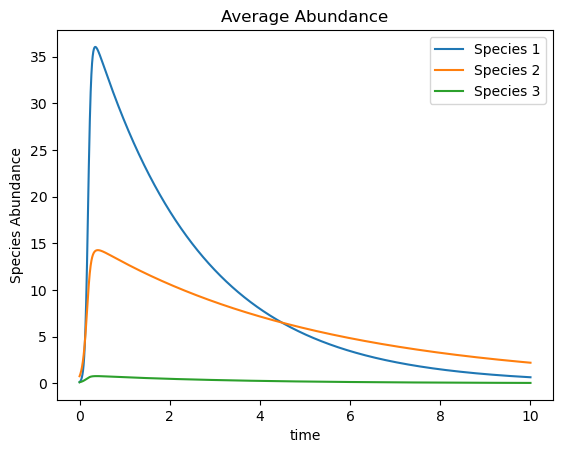

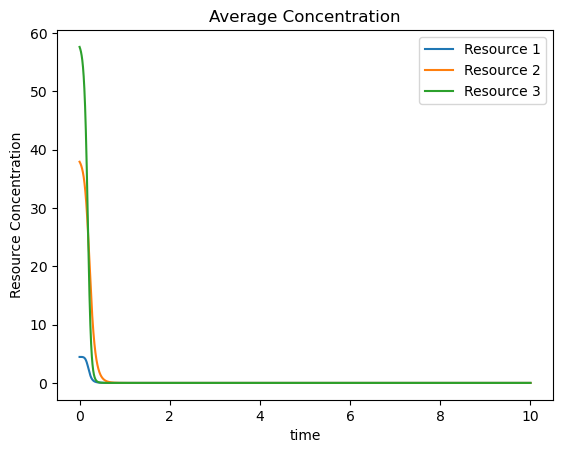

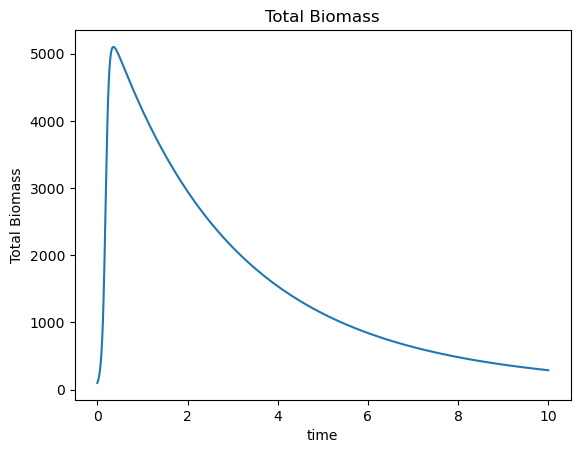

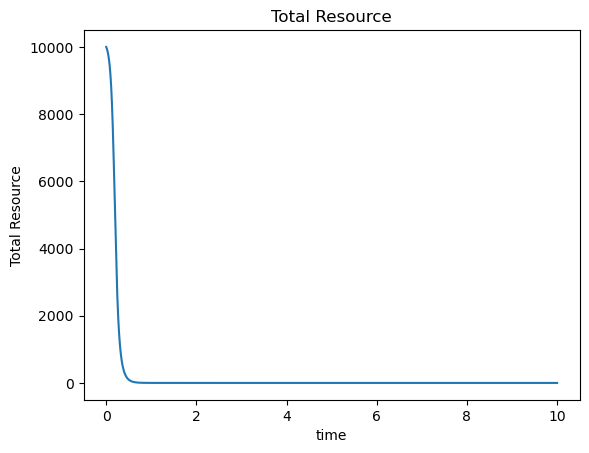

In [94]:
colors = ['k','r']
#stride = 1000
for i in range(S):
    plt.plot(tm, np.mean(N_solutions[:, i],axis = -1), label=f'Species {i+1}')
plt.title('Average Abundance')
plt.xlabel('time')
plt.ylabel('Species Abundance')
plt.legend()
plt.show()

stride = 1
for i in range(M):
    plt.plot(tm, np.mean(R_solutions[:, i],axis = -1), label=f'Resource {i+1}')
plt.title('Average Concentration')
plt.xlabel('time')
plt.ylabel('Resource Concentration')
plt.legend()
plt.show()

#total biomass
plt.plot(tm, np.sum(N_solutions, axis=(1, 2)))
plt.title('Total Biomass')
plt.xlabel('time')
plt.ylabel('Total Biomass')
plt.show()

#total resource
plt.plot(tm, np.sum(R_solutions, axis=(1, 2)))
plt.title('Total Resource')
plt.xlabel('time')
plt.ylabel('Total Resource')
plt.show()

In [95]:
print(ODE_final,PDE_final)

[0.64751808 2.19281799 0.0401696 ] [0.646225787917824 2.2040835486016275 0.04025428464317976]


In [ ]:
def run_comparison(S,M,L,nrep,Chemostat_flag=Fa):
    